In [1]:
from heaict.mobo.utility import find_pareto_front
from heaict.cats.problem import round_preserve_sum
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

read in data

In [2]:
# read in data
X_HEA = {}
Y_HEA = {}
X_HEI = {}
Y_HEI = {}
for sys in ['MoMn', 'MoRu', 'MoFe']:
    X_HEA[sys] = np.load(os.path.join(f'Data/XY_data/HEA_mobo3/', sys, 'X.npy'))
    Y_HEA[sys] = np.load(os.path.join(f'Data/XY_data/HEA_mobo3/', sys, 'Y.npy'))
    X_HEI[sys] = np.load(os.path.join(f'Data/XY_data/HEI_mobo3/', sys, 'X.npy'))
    Y_HEI[sys] = np.load(os.path.join(f'Data/XY_data/HEI_mobo3/', sys, 'Y.npy'))
sys='MoCo'
X_HEI[sys] = np.load(os.path.join(f'Data/XY_data/HEI_mobo3/', sys, 'X.npy'))
Y_HEI[sys] = np.load(os.path.join(f'Data/XY_data/HEI_mobo3/', sys, 'Y.npy'))

check max and min

In [3]:
for sys in ['MoMn', 'MoRu', 'MoFe']:
    print(sys, 'v', np.max(Y_HEA[sys][:, 0]), np.min(Y_HEA[sys][:, 0]))
    print(sys, 'FE', np.max(Y_HEA[sys][:, 1]), np.min(Y_HEA[sys][:, 1]))
    print(sys, 'G', np.max(Y_HEA[sys][:, 2]), np.min(Y_HEA[sys][:, 2]))

MoMn v 5.50301159222589 1.6915689028118113
MoMn FE -0.02921600358702304 -0.5738615534846674
MoMn G -7.0707205717083 -25.46096903280042
MoRu v 7.877030392481363 2.163036981043345
MoRu FE -0.0043464285135336915 -0.55188647670075
MoRu G -9.762887074824702 -19.13907205394
MoFe v 7.480658445017918 2.4735530448448886
MoFe FE -0.007004285976539062 -0.4152809915570268
MoFe G -2.23738864689933 -17.02965492606178


In [4]:
for sys in ['MoMn', 'MoRu', 'MoFe', 'MoCo']:
    print(sys, 'v', np.max(Y_HEI[sys][:, 0]), np.min(Y_HEI[sys][:, 0]))
    print(sys, 'FE', np.max(Y_HEI[sys][:, 1]), np.min(Y_HEI[sys][:, 1]))
    print(sys, 'G', np.max(Y_HEI[sys][:, 2]), np.min(Y_HEI[sys][:, 2]))

MoMn v 7.085390123542133 1.7408948534941064
MoMn FE -0.0039352757416584085 -0.7690385315325172
MoMn G 5482.96550242718 -15718.872507854787
MoRu v 7.982330050958127 2.2261098407701247
MoRu FE -0.00894481765780994 -0.5830020170964401
MoRu G 5524.6317435406745 -10798.184823367406
MoFe v 7.225897562468959 2.2778343032246604
MoFe FE -0.008571779578255063 -0.690189991877559
MoFe G 4277.572872629913 -14715.23310834453
MoCo v 7.4489866830629845 2.072243770294529
MoCo FE -0.010764270750782826 -0.827996902644631
MoCo G 5387.938787991838 -10850.063705436402


In [14]:
np.exp(-8.124411719187393-(-9.03903159982341))

2.4958263596417143

In [30]:
-np.log(0.00011868571608905117*500)

2.8244235014012182

In [3]:
# optimal solutions
HEA_optimal = np.array([  1.6915689 ,  -0.57386155, -21.40919093])
HEI_optimal = np.array([ 2.04377825e+00, -7.37131160e-01, -3.93866338e+02])

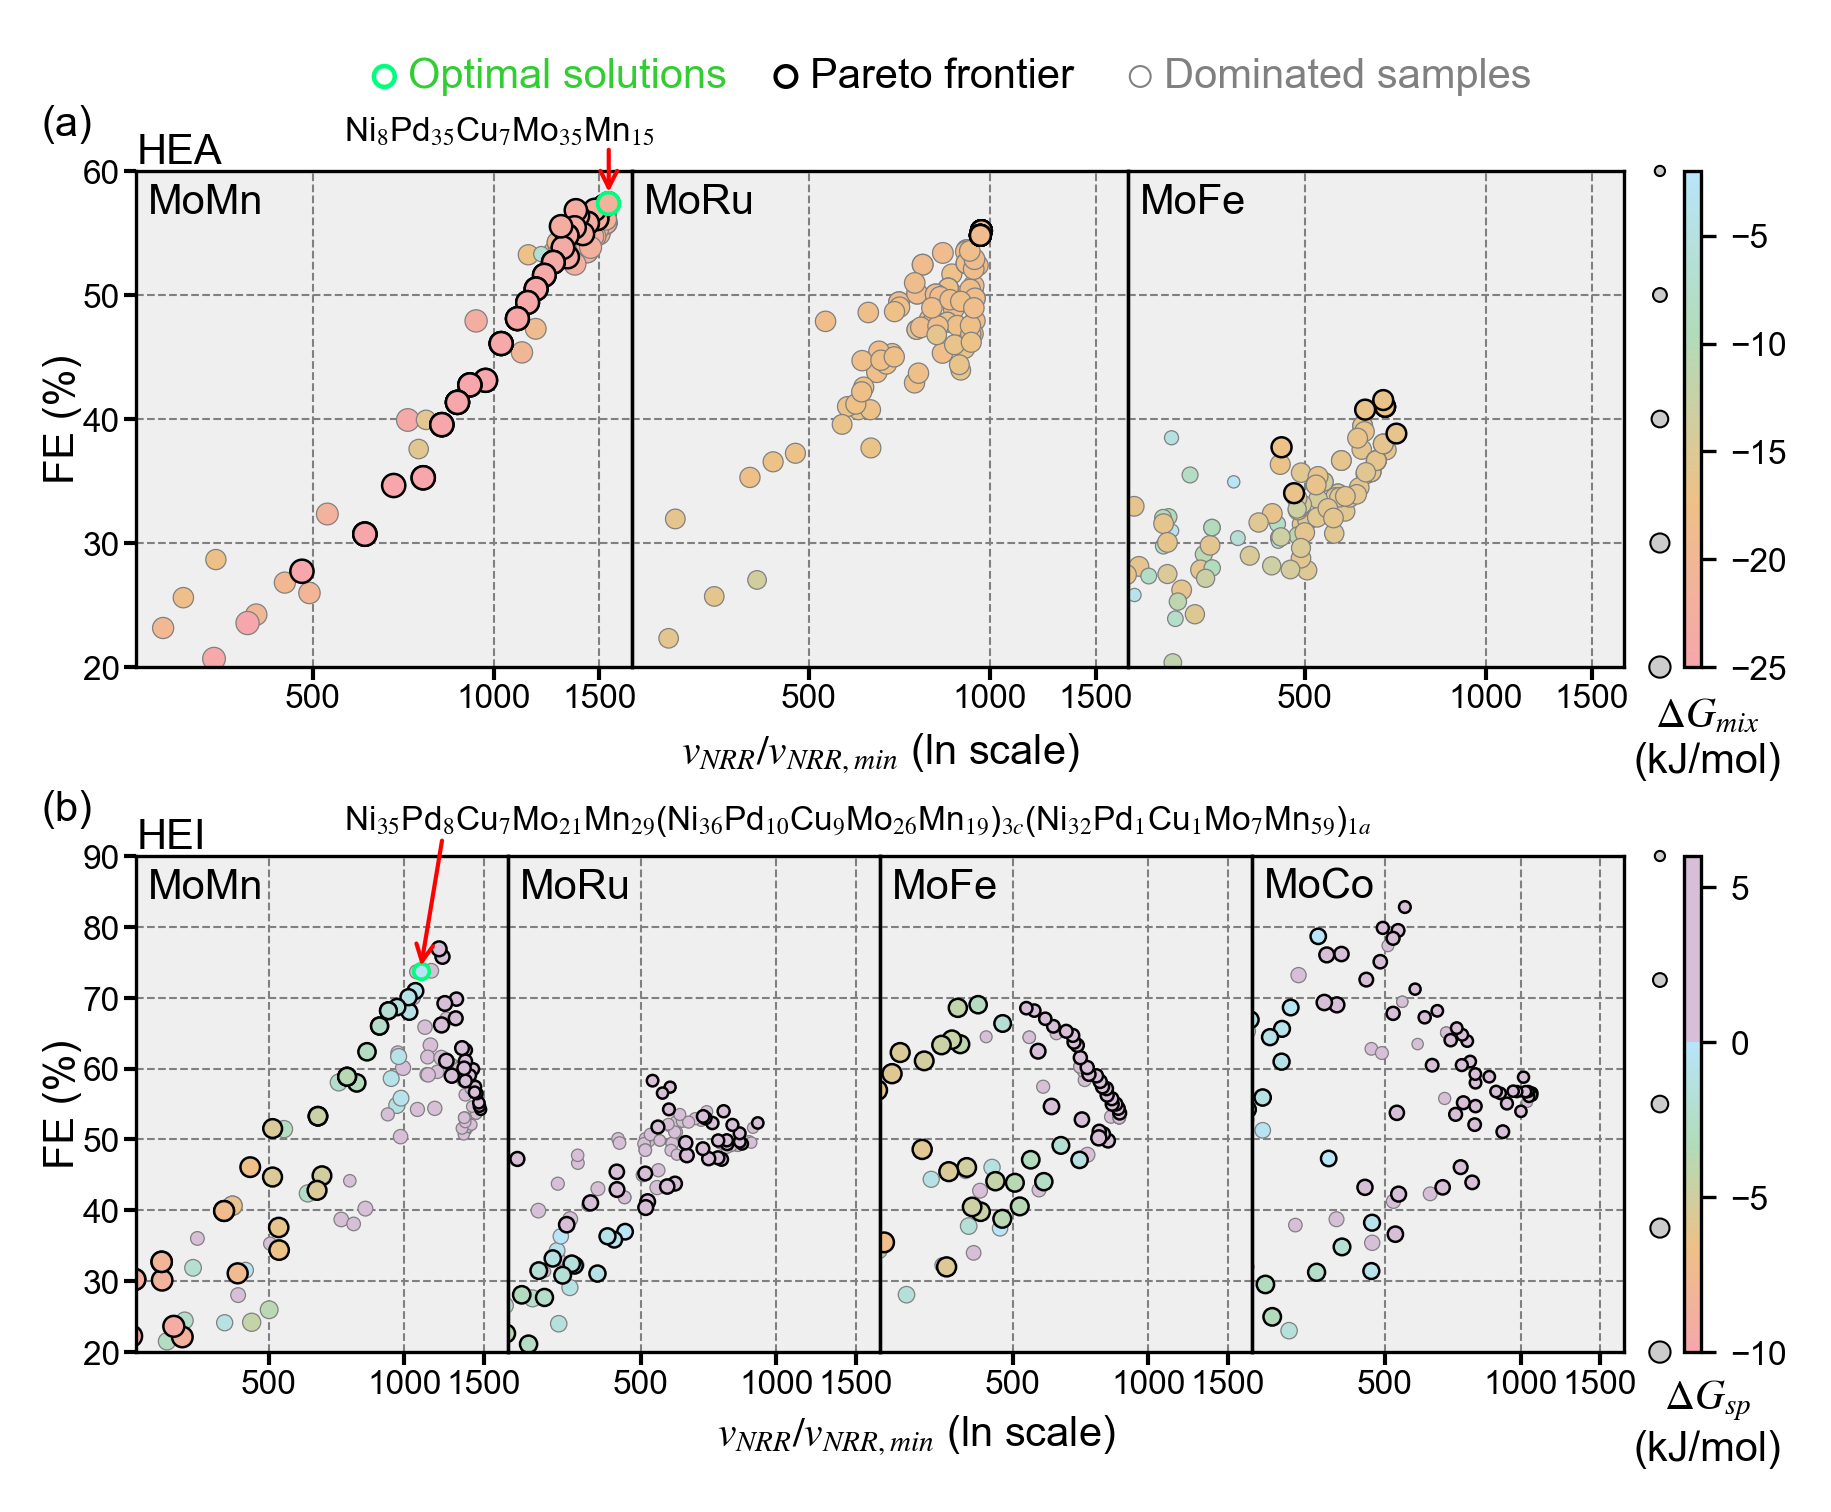

In [4]:
plt.rc('font', family='Arial')
plt.rcParams['mathtext.fontset'] = 'stix'

l=15; h=12.3
fig=plt.figure(figsize=(l/2.54, h/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0); ax0.set_zorder(6)


smin = 6; smax = 26; Ls = smax - smin

# HEA
vmin = -25; vmax = -2
cmap_HEA=LinearSegmentedColormap.from_list(name='xx', colors=list(zip([0, 0.333, 0.667, 1], ['#F7A6AC', '#EEC186', '#B2DBB9', '#B8E5FA', '#7C7CBA', '#7C7CBA'])))
ylim=(0.2, 0.6); yticks = [0.2, 0.3, 0.4, 0.5, 0.6]; ytl = [20, 30, 40, 50, 60]
xlim=(3.5, 1.6); xt = [1.726, 2.131, 2.824]; xtl = [1500, 1000, 500]
sys='MoMn' #=======================
ax1=fig.add_axes([0.9/l, 6.9/h, 4.2/l, 4.2/h]);ax1.tick_params(length=3,width=1,labelsize=8,pad=1)
ax1.set_facecolor('#CCCCCC');ax1.patch.set_alpha(0.3)
ax1.set_xlim(*xlim); ax1.set_ylim(*ylim)
ax1.set_ylabel('FE (%)', fontsize=10, labelpad=0); ax1.set_yticks(yticks); ax1.set_yticklabels(ytl)
ax1.set_xticks(xt); ax1.set_xticklabels(xtl)
ax1.scatter(Y_HEA[sys][:, 0], -1*Y_HEA[sys][:, 1], c=Y_HEA[sys][:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEA, ec='grey', lw=0.3, s=smin+(0.58-Y_HEA[sys][:, 2])/20.78*Ls, zorder=1)
py, pyi=find_pareto_front(Y_HEA[sys])
ax1.scatter(py[:, 0], -1*py[:, 1], c=py[:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEA, ec='k', lw=0.6, s=smin+(0.58-py[:, 2])/20.78*Ls, zorder=2)
ax1.scatter([HEA_optimal[0]], [-1*HEA_optimal[1]], c=[HEA_optimal[2]], vmin=vmin, vmax=vmax, cmap=cmap_HEA, ec='springgreen', lw=0.9, s=smin+(0.58-HEA_optimal[2])/20.78*Ls, zorder=2)
for y in yticks[1:-1]: ax1.plot(xlim, [y] * 2, c='grey', ls='--', lw=0.5, zorder=0)
for x in xt: ax1.plot([x] * 2, ylim, c='grey', ls='--', lw=0.5, zorder=0)
sys='MoRu' #=======================
ax2=fig.add_axes([5.1/l, 6.9/h, 4.2/l, 4.2/h]);ax2.tick_params(length=3,width=1,labelsize=8,pad=1)
ax2.set_facecolor('#CCCCCC');ax2.patch.set_alpha(0.3)
ax2.set_xlim(*xlim); ax2.set_ylim(*ylim)
ax2.set_yticks([])
ax2.set_xticks(xt); ax2.set_xticklabels(xtl); ax2.set_xlabel('$v_{NRR}/v_{NRR,min}$ (ln scale)', fontsize=10)
ax2.scatter(Y_HEA[sys][:, 0], -1*Y_HEA[sys][:, 1], c=Y_HEA[sys][:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEA, ec='grey', lw=0.3, s=smin+(0.58-Y_HEA[sys][:, 2])/20.78*Ls, zorder=1)
py, pyi=find_pareto_front(Y_HEA[sys])
ax2.scatter(py[:, 0], -1*py[:, 1], c=py[:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEA, ec='k', lw=0.6, s=smin+(0.58-py[:, 2])/20.78*Ls, zorder=2)
for y in yticks[1:-1]: ax2.plot(xlim, [y] * 2, c='grey', ls='--', lw=0.5, zorder=0)
for x in xt: ax2.plot([x] * 2, ylim, c='grey', ls='--', lw=0.5, zorder=0)
sys='MoFe' #=======================
ax3=fig.add_axes([9.3/l, 6.9/h, 4.2/l, 4.2/h]);ax3.tick_params(length=3,width=1,labelsize=8,pad=1)
ax3.set_facecolor('#CCCCCC');ax3.patch.set_alpha(0.3)
ax3.set_xlim(*xlim); ax3.set_ylim(*ylim)
ax3.set_yticks([])
ax3.set_xticks(xt); ax3.set_xticklabels(xtl)
ax3.scatter(Y_HEA[sys][:, 0], -1*Y_HEA[sys][:, 1], c=Y_HEA[sys][:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEA, ec='grey', lw=0.3, s=smin+(0.58-Y_HEA[sys][:, 2])/20.78*Ls, zorder=1)
py, pyi=find_pareto_front(Y_HEA[sys])
ax3.scatter(py[:, 0], -1*py[:, 1], c=py[:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEA, ec='k', lw=0.6, s=smin+(0.58-py[:, 2])/20.78*Ls, zorder=2)
for y in yticks[1:-1]: ax3.plot(xlim, [y] * 2, c='grey', ls='--', lw=0.5, zorder=0)
for x in xt: ax3.plot([x] * 2, ylim, c='grey', ls='--', lw=0.5, zorder=0)
# color bar
cax = fig.add_axes([14/l, 6.9/h, 0.15/l, 4.2/h])
cb = ColorbarBase(cax, cmap=cmap_HEA,norm=Normalize(vmin=vmin, vmax=vmax))
cb.ax.tick_params(labelsize=8)
ax0.scatter([13.8/l, 13.8/l, 13.8/l, 13.8/l, 13.8/l], [6.9/h, 7.95/h, 9/h, 10.05/h, 11.1/h], s=[26, 21, 16, 11, 6], c='#CCCCCC', ec='k', lw=0.5)
ax0.text(14.2/l, 6.3/h, '$\Delta G_{mix}$\n(kJ/mol)', fontsize=10, ha='center', va='center')

# HEI
# vmin = -75000; vmax = -58000
vmin = -10000; vmax = 6000
cmap_HEI=LinearSegmentedColormap.from_list(name='xx', colors=list(zip([0, 0.2083, 0.4166, 0.625, 0.6251, 1], ['#F7A6AC', '#EEC186', '#B2DBB9', '#B8E5FA', '#D8BFD8', '#D8BFD8'])))
ylim=(0.2, 0.9); yticks = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]; ytl = [20, 30, 40, 50, 60, 70, 80, 90]
xlim=(3.5, 1.6); xt = [1.726, 2.131, 2.824]; xtl = [1500, 1000, 500]
sys='MoMn'
ax4=fig.add_axes([0.9/l, 1.1/h, 3.15/l, 4.2/h]);ax4.tick_params(length=3,width=1,labelsize=8,pad=1)
ax4.set_ylabel('FE (%)', fontsize=10, labelpad=0); ax4.set_facecolor('#CCCCCC'); ax4.patch.set_alpha(0.3)
ax4.set_xlim(*xlim); ax4.set_ylim(*ylim)
ax4.set_yticks(yticks); ax4.set_yticklabels(ytl);ax4.set_xticks(xt); ax4.set_xticklabels(xtl)
ax4.scatter(Y_HEI[sys][:, 0], -1*Y_HEI[sys][:, 1], c=Y_HEI[sys][:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='grey', lw=0.3, s=smin+(vmax-Y_HEI[sys][:, 2])/(vmax-vmin)*Ls, zorder=1)
py, pyi=find_pareto_front(Y_HEI[sys])
ax4.scatter(py[:, 0], -1*py[:, 1], c=py[:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='k', lw=0.6, s=smin+(vmax-py[:, 2])/(vmax-vmin)*Ls, zorder=2)
ax4.scatter([HEI_optimal[0]], [-1*HEI_optimal[1]], c=HEI_optimal[2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='springgreen', lw=0.9, s=smin+(vmax-HEI_optimal[2])/(vmax-vmin)*Ls, zorder=2)
for y in yticks[1:-1]: ax4.plot(xlim, [y] * 2, c='grey', ls='--', lw=0.5, zorder=0)
for x in xt: ax4.plot([x] * 2, ylim, c='grey', ls='--', lw=0.5, zorder=0)
sys='MoRu'
ax5=fig.add_axes([(0.9+(3.15))/l, 1.1/h, 3.15/l, 4.2/h]);ax5.tick_params(length=3,width=1,labelsize=8,pad=1)
ax5.set_facecolor('#CCCCCC'); ax5.patch.set_alpha(0.3)
ax5.set_xlim(*xlim); ax5.set_ylim(*ylim)
ax5.set_yticks([]); ax5.set_xticks(xt); ax5.set_xticklabels(xtl)
ax5.scatter(Y_HEI[sys][:, 0], -1*Y_HEI[sys][:, 1], c=Y_HEI[sys][:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='grey', lw=0.3, s=smin+(vmax-Y_HEI[sys][:, 2])/(vmax-vmin)*Ls, zorder=1)
py, pyi=find_pareto_front(Y_HEI[sys])
ax5.scatter(py[:, 0], -1*py[:, 1], c=py[:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='k', lw=0.6, s=smin+(vmax-py[:, 2])/(vmax-vmin)*Ls, zorder=2)
for y in yticks[1:-1]: ax5.plot(xlim, [y] * 2, c='grey', ls='--', lw=0.5, zorder=0)
for x in xt: ax5.plot([x] * 2, ylim, c='grey', ls='--', lw=0.5, zorder=0)
sys='MoFe'
ax6=fig.add_axes([(0.9+3.15*2)/l, 1.1/h, 3.15/l, 4.2/h]);ax6.tick_params(length=3,width=1,labelsize=8,pad=1)
ax6.set_facecolor('#CCCCCC'); ax6.patch.set_alpha(0.3)
ax6.set_xlim(*xlim); ax6.set_ylim(*ylim)
ax6.set_yticks([]); ax6.set_xticks(xt); ax6.set_xticklabels(xtl)
ax6.scatter(Y_HEI[sys][:, 0], -1*Y_HEI[sys][:, 1], c=Y_HEI[sys][:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='grey', lw=0.3, s=smin+(vmax-Y_HEI[sys][:, 2])/(vmax-vmin)*Ls, zorder=1)
py, pyi=find_pareto_front(Y_HEI[sys])
ax6.scatter(py[:, 0], -1*py[:, 1], c=py[:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='k', lw=0.6, s=smin+(vmax-py[:, 2])/(vmax-vmin)*Ls, zorder=2)
for y in yticks[1:-1]: ax6.plot(xlim, [y] * 2, c='grey', ls='--', lw=0.5, zorder=0)
for x in xt: ax6.plot([x] * 2, ylim, c='grey', ls='--', lw=0.5, zorder=0)
sys='MoCo'
ax7=fig.add_axes([(0.9+3.15*3)/l, 1.1/h, 3.15/l, 4.2/h]);ax7.tick_params(length=3,width=1,labelsize=8,pad=1)
ax7.set_facecolor('#CCCCCC'); ax7.patch.set_alpha(0.3)
ax7.set_xlim(*xlim); ax7.set_ylim(*ylim)
ax7.set_yticks([]); ax7.set_xticks(xt); ax7.set_xticklabels(xtl)
ax7.scatter(Y_HEI[sys][:, 0], -1*Y_HEI[sys][:, 1], c=Y_HEI[sys][:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='grey', lw=0.3, s=smin+(vmax-Y_HEI[sys][:, 2])/(vmax-vmin)*Ls, zorder=1)
py, pyi=find_pareto_front(Y_HEI[sys])
ax7.scatter(py[:, 0], -1*py[:, 1], c=py[:, 2], vmin=vmin, vmax=vmax, cmap=cmap_HEI, ec='k', lw=0.6, s=smin+(vmax-py[:, 2])/(vmax-vmin)*Ls, zorder=2)
for y in yticks[1:-1]: ax7.plot(xlim, [y] * 2, c='grey', ls='--', lw=0.5, zorder=0)
for x in xt: ax7.plot([x] * 2, ylim, c='grey', ls='--', lw=0.5, zorder=0)

ax0.text(7.5/l, 0.4/h, '$v_{NRR}/v_{NRR,min}$ (ln scale)', fontsize=10, ha='center', va='center')

cax = fig.add_axes([14/l, 1.1/h, 0.15/l, 4.2/h])
cb = ColorbarBase(cax, cmap=cmap_HEI,norm=Normalize(vmin=vmin/1000, vmax=vmax/1000))
cb.ax.tick_params(labelsize=8)
cb.ax.set_yticks([-10, -5, 0, 5])
ax0.scatter([13.8/l, 13.8/l, 13.8/l, 13.8/l, 13.8/l], [1.1/h, 2.15/h, 3.2/h, 4.25/h, 5.3/h], s=[26, 21, 16, 11, 6], c='#CCCCCC', ec='k', lw=0.5)
ax0.text(14.2/l, 0.5/h, '$\Delta G_{sp}$\n(kJ/mol)', fontsize=10, ha='center', va='center')

# main 
ax0.scatter([3.0/l], [11.9/h], s=25, c='none', ec='springgreen', lw=1.1)
ax0.text(3.2/l, 11.9/h, 'Optimal solutions', fontsize=10, ha='left', va='center', c='limegreen')
ax0.scatter([6.4/l], [11.9/h], s=25, c='none', ec='k', lw=1)
ax0.text(6.6/l, 11.9/h, 'Pareto frontier ', fontsize=10, ha='left', va='center')
ax0.scatter([9.4/l], [11.9/h], s=25, c='none', ec='grey', lw=0.5)
ax0.text(9.6/l, 11.9/h, 'Dominated samples', fontsize=10, ha='left', va='center', c='grey')

ax0.text(0.1/l, (6.9+4.2+0.3)/h, '(a)', fontsize=10)
ax0.text(0.9/l, (6.9+4.2)/h, 'HEA', fontsize=10, va='bottom', ha='left')
ax0.text(1.0/l, (6.9+4.2-0.1)/h, 'MoMn', fontsize=10, va='top', ha='left')
ax0.text((1.0+4.2*1)/l, (6.9+4.2-0.1)/h, 'MoRu', fontsize=10, va='top', ha='left')
ax0.text((1.0+4.2*2)/l, (6.9+4.2-0.1)/h, 'MoFe', fontsize=10, va='top', ha='left')
ax0.text(0.1/l, 5.6/h, '(b)', fontsize=10)
ax0.text(0.9/l, (5.3)/h, 'HEI', fontsize=10, va='bottom', ha='left')
ax0.text(1.0/l, (5.3-0.1)/h, 'MoMn', fontsize=10, va='top', ha='left')
ax0.text((1.0+3.15)/l, (5.3-0.1)/h, 'MoRu', fontsize=10, va='top', ha='left')
ax0.text((1.0+3.15*2)/l, (5.3-0.1)/h, 'MoFe', fontsize=10, va='top', ha='left')
ax0.text((1.0+3.15*3)/l, (5.3-0.1)/h, 'MoCo', fontsize=10, va='top', ha='left')

arrow = FancyArrowPatch((4.9/l, (6.9+4.45)/h), (4.9/l, (6.9+3.95)/h), arrowstyle='->', mutation_scale=10, color='red', lw=1., zorder=0)
ax0.add_patch(arrow)
ax0.text(2.66/l, (6.9+4.4)/h, 'Ni$_{8}$Pd$_{35}$Cu$_{7}$Mo$_{35}$Mn$_{15}$', fontsize=8, va='bottom', ha='left')
arrow = FancyArrowPatch((3.5/l, (5.5)/h), (3.3/l, (4.3)/h), arrowstyle='->', mutation_scale=10, color='red', lw=1., zorder=0)
ax0.add_patch(arrow)
ax0.text(2.66/l, (5.45)/h, 'Ni$_{35}$Pd$_{8}$Cu$_{7}$Mo$_{21}$Mn$_{29}$(Ni$_{36}$Pd$_{10}$Cu$_{9}$Mo$_{26}$Mn$_{19}$)$_{3c}$(Ni$_{32}$Pd$_{1}$Cu$_{1}$Mo$_{7}$Mn$_{59}$)$_{1a}$', fontsize=8, va='bottom', ha='left')
# plt.show()
# fig.savefig('Figure_5.tif',dpi=300)